## RQ1: Can the next pitch type thrown by a Blue Jays pitcher be predicted using pitch context and game state? 

In [ ]:
# Import necessary libraries and suppress warnings
import warnings
warnings.filterwarnings('ignore')

import pandas                  as pd
import numpy                   as np
import matplotlib.pyplot       as plt
import seaborn                 as sns
import statsmodels.api         as sm
import statsmodels.formula.api as smf
from sklearn import metrics
from sklearn import dummy
from sklearn import ensemble
from scipy.stats import chi2_contingency
# This statement allow to display plot without asking to 
%matplotlib inline

# always make it pretty 
plt.style.use('ggplot')

## Plan (subject to change)

Game State:

`inning` - which inning

`outs_when_up` - number of outs


`balls`, `strikes` - the count


`bat_score`, `fld_score` - score differential ( score_diff = `fld_score` - `bat_score`)


`on_1b`, `on_2b`, `on_3b` - baserunners (convert to binary 0/1)



Pitch Context (lag features):


`prev_pitch_name` - the previous pitch type in the at-bat

`prev_pitch_name_2` - two pitches ago in the at-bat

`pitch_number_in_ab` - which pitch number within the at-bat


`cumulative_pitch_count` - pitcher's total pitch count so far in the game



Batter/Pitcher Identity:

`stand` -- batter handedness (L/R)


`p_throws` -- pitcher hand (L/R)


`player_name` -- pitcher identity (label-encoded or one-hot if few enough)



In [ ]:
# Import Blue Jays dataframe 
%store -r bj_df

# Sort dataframe in a chronological order for lag features
# Sort by game_pk - pitches from game 1, game 2,..
# Sort by at_bat_number - pitches at-bat 1, at-bat 2,..
# Sort by pitch_number - pitches from each at-bat
sorted_bj = bj_df.sort_values(by=['game_pk', 'at_bat_number', 'pitch_number']).reset_index(drop=True)

# Pitch context (lag features)
# ab = at-bat
ab_group = sorted_bj.groupby(['game_pk', 'at_bat_number'])
sorted_bj['prev_pitch_name']   = ab_group['pitch_name'].shift(1)
sorted_bj['pitch_number_in_ab'] = ab_group.cumcount()

# Pitcher's cumulative pitch count in a game
sorted_bj['cumulative_pitch_count'] = sorted_bj.groupby(['game_pk', 'pitcher']).cumcount()

# Game state
sorted_bj['score_diff'] = sorted_bj['fld_score'] - sorted_bj['bat_score']

# Baserunners: NaN means base is empty = 0, player id = 1
sorted_bj['on_1b_flag'] = sorted_bj['on_1b'].notna().astype(int)
sorted_bj['on_2b_flag'] = sorted_bj['on_2b'].notna().astype(int)
sorted_bj['on_3b_flag'] = sorted_bj['on_3b'].notna().astype(int)

# Combined count state for easier categorical encoding
sorted_bj['count_state'] = sorted_bj['balls'].astype(str) + '-' + sorted_bj['strikes'].astype(str)

sorted_bj[['player_name', 'pitch_name', 'prev_pitch_name',
           'pitch_number_in_ab', 'cumulative_pitch_count', 'score_diff',
           'on_1b_flag', 'on_2b_flag', 'on_3b_flag', 'count_state',
           'balls', 'strikes', 'inning', 'outs_when_up', 'stand', 'p_throws']].head(10)

,player_name,pitch_name,prev_pitch_name,pitch_number_in_ab,cumulative_pitch_count,score_diff,on_1b_flag,on_2b_flag,on_3b_flag,count_state,balls,strikes,inning,outs_when_up,stand,p_throws
0,"Yesavage, Trey",4-Seam Fastball,NaN,0,0,2,0,0,0,0-0,0,0,1,0,L,R
1,"Yesavage, Trey",Split-Finger,4-Seam Fastball,1,1,2,0,0,0,1-0,1,0,1,0,L,R
2,"Yesavage, Trey",Slider,Split-Finger,2,2,2,0,0,0,1-1,1,1,1,0,L,R
3,"Yesavage, Trey",Split-Finger,Slider,3,3,2,0,0,0,1-2,1,2,1,0,L,R
4,"Yesavage, Trey",Slider,Split-Finger,4,4,2,0,0,0,2-2,2,2,1,0,L,R
5,"Yesavage, Trey",4-Seam Fastball,Slider,5,5,2,0,0,0,2-2,2,2,1,0,L,R
6,"Yesavage, Trey",4-Seam Fastball,NaN,0,6,2,0,0,0,0-0,0,0,1,1,R,R
7,"Yesavage, Trey",4-Seam Fastball,4-Seam Fastball,1,7,2,0,0,0,0-1,0,1,1,1,R,R
8,"Yesavage, Trey",4-Seam Fastball,NaN,0,8,2,0,0,0,0-0,0,0,1,2,R,R
9,"Yesavage, Trey",Slider,4-Seam Fastball,1,9,2,0,0,0,0-1,0,1,1,2,R,R


# Pitch Type Distribution

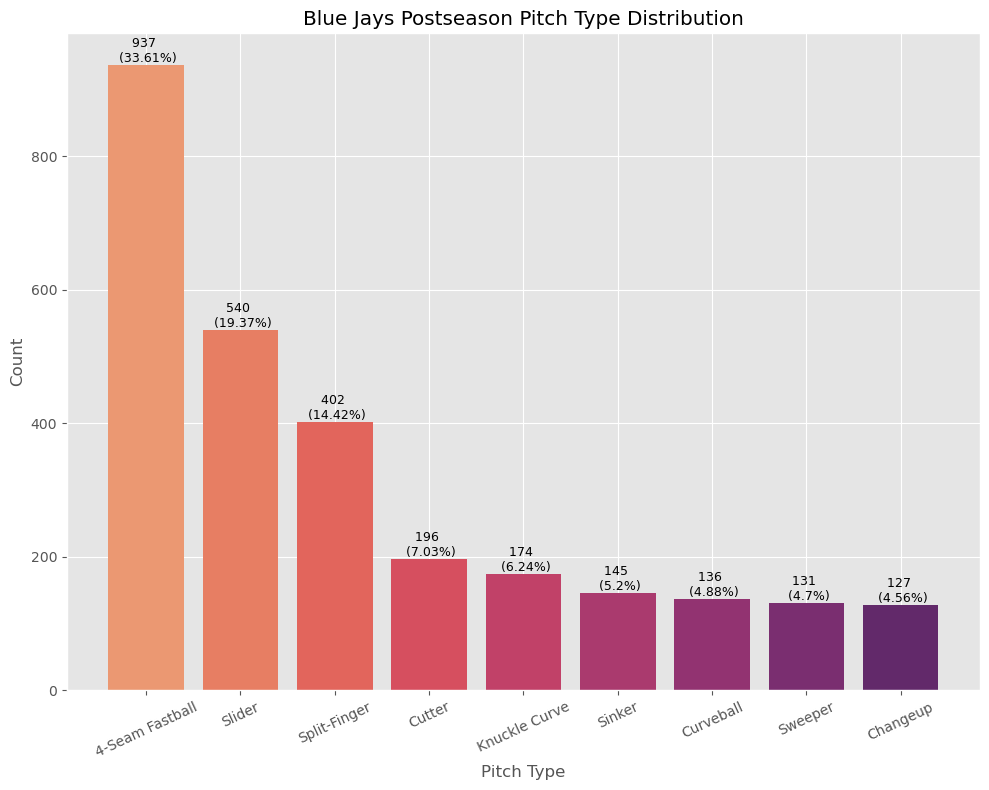

In [ ]:
pitch_counts = sorted_bj['pitch_name'].value_counts()
total = len(sorted_bj)

plt.figure(figsize=(10, 8))
bars = plt.bar(pitch_counts.index, pitch_counts.values, color=sns.color_palette('flare', len(pitch_counts)))

for bar, count in zip(bars, pitch_counts.values):
    percent = count / total * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{count} \n ({round(percent,2)}%)', ha='center', va='bottom', fontsize=9)

plt.xlabel('Pitch Type')
plt.ylabel('Count')
plt.title('Blue Jays Postseason Pitch Type Distribution')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

The pitch type distribution is imbalanced. The 4-Seam Fastball dominates the rest, which is expected in MLB since fastballs are the foundation for most pitchers. This imbalance sets our naive baseline: a model that always predicts "4-Seam Fastball" would achieve accuracy equal to the fastball's usage rate. Our trained models must significantly exceed this threshold to demonstrate that pitch selection is  predictable from context.

# Pitch usage by count

Rows = pitch type, 
columns = count state, 
values = proportion within each count

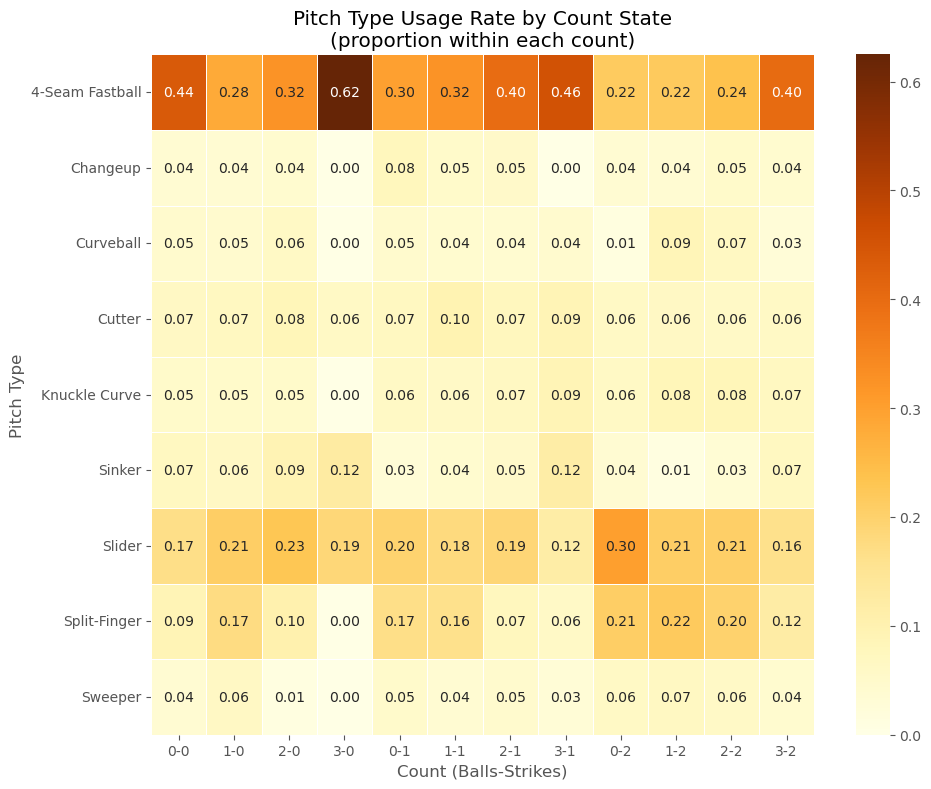

In [ ]:
count_order = ['0-0','1-0','2-0','3-0',
               '0-1','1-1','2-1','3-1',
               '0-2','1-2','2-2','3-2']

crosstab = pd.crosstab(sorted_bj['pitch_name'], sorted_bj['count_state'], normalize='columns')
crosstab = crosstab[count_order]

plt.figure(figsize=(10, 8))
sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='YlOrBr', linewidths=0.5)
plt.title('Pitch Type Usage Rate by Count State\n(proportion within each count)')
plt.xlabel('Count (Balls-Strikes)')
plt.ylabel('Pitch Type')
plt.tight_layout()
plt.show()

The heatmap reveals clear count-dependent pitch selection patterns. On hitter-favored counts (3-0, 3-1, 2-0), fastball usage spikes, meaning pitchers need to throw strikes and default to their most reliable pitch. On pitcher-favored counts (0-2, 1-2), off-speed and breaking ball usage increases as pitchers try to get batters to chase pitches outside the zone. The fact that pitch mix shifts meaningfully across count states is strong visual evidence that the count is a useful predictor for our model. We can say that the pitch selection is influenced by the game situation.

# Pitch transition matrix
Only rows where prev_pitch_name exists (not the first pitch of an at-bat)

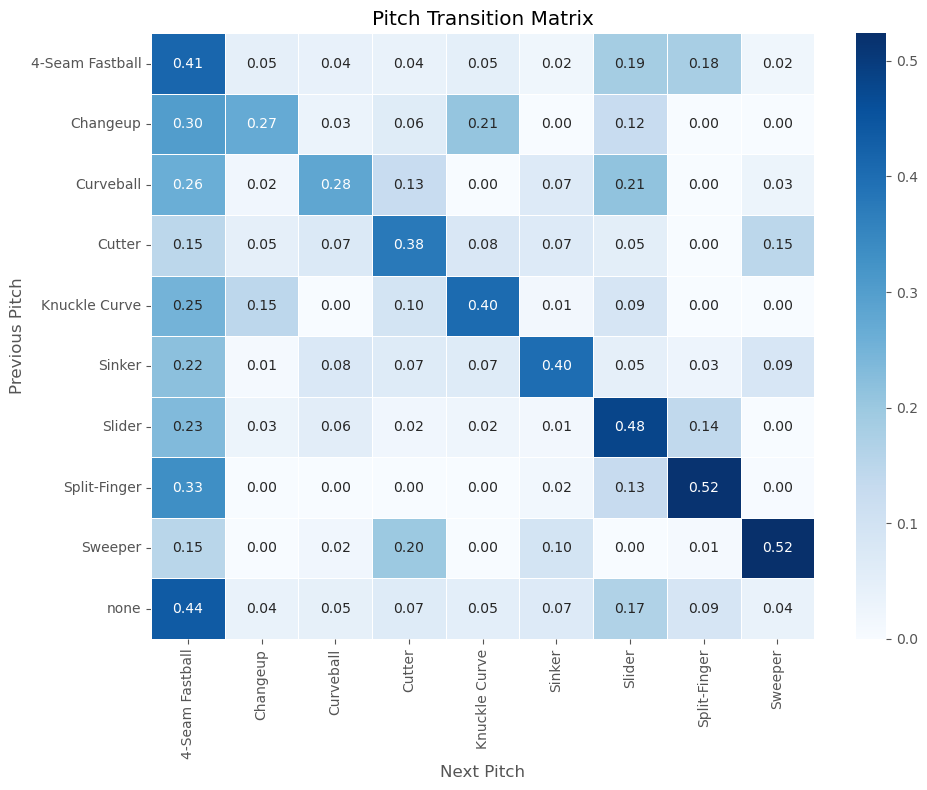

In [ ]:
seq_df = sorted_bj.dropna(subset=['prev_pitch_name'])

transition = pd.crosstab(seq_df['prev_pitch_name'], seq_df['pitch_name'], normalize='index')

plt.figure(figsize=(10, 8))
sns.heatmap(transition, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Pitch Transition Matrix')
plt.xlabel('Next Pitch')
plt.ylabel('Previous Pitch')
plt.tight_layout()
plt.show()

The transition matrix shows the probability of each pitch type given the pitch that was just thrown. Interpret the graph like this: `if the previous pitch was [row], then the next pitch is [column] with the probability of N.` If pitchers were selecting pitches completely at random, completely independent of the previous pitch, every row would look identical. However, rows differ from each other tells us that sequencing patterns exist, which means knowing what the previous pitch was changes the probability distribution of the next pitch. This shows that `prev_pitch_name` will be a valuable feature for our prediction models.

# Chi-Square Test: Is Pitch Selection Independent of Count?

The visualizations above suggest that pitch usage varies across count states. The chi-square test of independence formalizes this: if the null hypothesis (pitch type and count state are independent) is rejected, we have **statistical evidence** that the count influences pitch selection -- further motivation for including `count_state` as a feature.

In [ ]:
contingency = pd.crosstab(sorted_bj['pitch_name'], columns=sorted_bj['count_state'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"p-value: {p_value}")

if p_value < 0.05:
    print("Result: Reject the null hypothesis at p = 0.05. Pitch selection is NOT independent of the count state.")
else:
    print("Result: Fail to reject the null hypothesis. No significant dependence found.")

p-value: 3.405858529772178e-14
Result: Reject the null hypothesis at p = 0.05. Pitch selection is NOT independent of the count state.


# One-Hot Encode and Train/Test Split
We select only the features a batter would know before the pitch is thrown to ensure no data leakage and one-hot encode the categorical columns. The first pitch of each at-bat has no previous pitch, so we fill that with `none`. We then perform a temporal train/test split based on each unique game (which increases chronologically). The first 80% of games form the training set and the remaining 20% form the test set.

In [ ]:
# Fill first pitch of each at-bat with none
sorted_bj['prev_pitch_name'] = sorted_bj['prev_pitch_name'].fillna('none')

# Define feature columns
categorical_features = ['prev_pitch_name', 'count_state', 'stand', 'p_throws', 'player_name']
numeric_features     = ['pitch_number_in_ab', 'cumulative_pitch_count', 'score_diff',
'on_1b_flag', 'on_2b_flag', 'on_3b_flag', 'inning', 'outs_when_up']

# Target var
y = sorted_bj['pitch_name']

# One-hot encode categorical
X_cat = pd.get_dummies(sorted_bj[categorical_features], drop_first=False, dtype=int)
X_num = sorted_bj[numeric_features].copy()
X = pd.concat([X_num, X_cat], axis=1)

# Train on the first 80% of games, test on the rest
unique_games = sorted_bj['game_pk'].unique()
split_index = int(len(unique_games) * 0.80)
train_games = set(unique_games[:split_index])

train_mask = sorted_bj['game_pk'].isin(train_games)
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Training set: {len(X_train)}")
print(f"Test set: {len(X_test)}")
print(f"Feature columns: {X.shape[1]}")

Training set: 2191
Test set: 597
Feature columns: 49


In [ ]:
print("One-hot encoded categorical features:")
for feat in categorical_features:
    cols = [c for c in X_cat.columns if c.startswith(feat + '_')]
    print(f"{feat}: {len(cols)} columns")
    
X.head()

One-hot encoded categorical features:
prev_pitch_name: 10 columns
count_state: 12 columns
stand: 2 columns
p_throws: 2 columns
player_name: 15 columns


,pitch_number_in_ab,cumulative_pitch_count,score_diff,on_1b_flag,on_2b_flag,on_3b_flag,inning,outs_when_up,prev_pitch_name_4-Seam Fastball,prev_pitch_name_Changeup,...,"player_name_Fluharty, Mason","player_name_Gausman, Kevin","player_name_Hoffman, Jeff","player_name_Lauer, Eric","player_name_Little, Brendon","player_name_Nance, Tommy","player_name_Rodríguez, Yariel","player_name_Scherzer, Max","player_name_Varland, Louis","player_name_Yesavage, Trey"
0,0,0,2,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,1,2,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1
2,2,2,2,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,3,3,2,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,4,4,2,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1


# Model Training and Comparison

1. `Naive Baseline` - Always predicts the most frequent pitch (4-Seam Fastball). This sets the accuracy floor which our models must clear.
2. `Random Forest Classifier` - If it beats the naive baseline, non-linear interactions between features (ex: a pitcher only throws curveballs on 0-2 counts) are important.

We use `5-fold stratified cross-validation` on the training set for hyperparameter tuning and report accuracy as the primary metric.

## Naive Baseline: Most-Frequent Pitch

This establishes the accuracy floor and if our trained models can't beat this, pitch selection is unpredictable using context.

In [ ]:
dum = dummy.DummyClassifier(strategy='most_frequent')
dum.fit(X_train, y_train)
y_pred_dummy = dum.predict(X_test)

naive_acc = metrics.accuracy_score(y_test, y_pred_dummy)

most_common = y_train.value_counts().idxmax()
print(f"Naive Baseline: always predict '{most_common}'")
print(f"Accuracy: {round(naive_acc * 100, 2)}%")

Naive Baseline: always predict '4-Seam Fastball'
Accuracy: 30.32%


## Random Forest Classifier

For our multiclass pitch-type prediction problem, the random forest assigns each pitch to the class that receives the most votes across all trees.

1. **5-fold stratified cross-validation** on the training set to estimate generalization performance and select hyperparameters
2. **Train a final model** on the full training set and evaluate on the held-out test set
3. **Confusion matrix, ROC curves, and feature importances** to interpret the model's behaviour

### 5-Fold Stratified Cross-Validation

We use cross validation with 5 folds to evaluate Random Forest models at different tree depths (3, 5, 8, 12). We fix `n_estimators=100` and `random_state=0` for reproducibility. For each depth, we record the mean and standard deviation of accuracy across folds to objectively select the best hyperparameter.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

depth_candidates = [3, 5, 8, 12]
cv_results = {}

for depth in depth_candidates:
    fold_accs = []
    for train_index, val_index in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
        y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]
        
        clf = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=0)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_val)
        fold_accs.append(accuracy_score(y_val, y_pred))
    
    mean_acc = np.mean(fold_accs)
    std_acc  = np.std(fold_accs)
    cv_results[depth] = (mean_acc, std_acc, fold_accs)

best_depth = max(cv_results, key=lambda d: cv_results[d][0])
print(f"\nBest max_depth = {best_depth}\nCV Accuracy = {cv_results[best_depth][0]:.4f} ± {cv_results[best_depth][1]:.4f}")


Best max_depth = 8
CV Accuracy = 0.4774 ± 0.0215


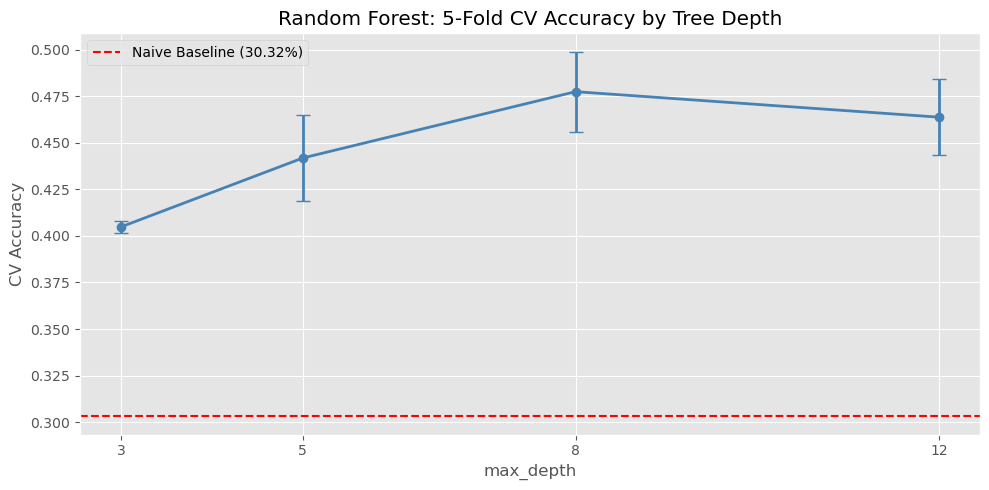

In [ ]:
depths = list(cv_results.keys())
means  = [cv_results[d][0] for d in depths]
stds   = [cv_results[d][1] for d in depths]

plt.figure(figsize=(10, 5))
plt.errorbar(depths, means, yerr=stds, fmt='-o', capsize=5, color='steelblue', linewidth=2)
plt.axhline(y=naive_acc, color='red', linestyle='--', linewidth=1.5, label=f'Naive Baseline ({naive_acc:.2%})')
plt.xlabel('max_depth')
plt.ylabel('CV Accuracy')
plt.title('Random Forest: 5-Fold CV Accuracy by Tree Depth')
plt.xticks(depths)
plt.legend()
plt.tight_layout()
plt.show()

**Cross-Validation Interpretation**

We found that:
- All depths beat the naive baseline, confirming that pitch selection is **not random** and the features we engineered carry predictive signal.
- Increasing `max_depth` does not always improve results and can lead to overfitting. We select the depth that maximizes mean CV accuracy with low variance across folds.
- The error bars (± 1 standard deviation) indicate the stability of each configuration across folds. A model with both high accuracy and low variance is preferred.

### Train Final Model and Evaluate on Test Set

Using the best `max_depth` selected from cross-validation, we now train the Random Forest on the entire training set and evaluate it on the held-out 20% test set that the model has never seen. This gives us an unbiased estimate of real-world performance.

In [ ]:
rf_final = RandomForestClassifier(n_estimators=100, max_depth=best_depth, random_state=0)
rf_final.fit(X_train, y_train)

y_pred_rf = rf_final.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest (max_depth={best_depth})")
print(f"Test Accuracy:  {round(rf_acc,3) * 100}%")
print(f"Naive Baseline: {round(naive_acc,3) * 100}%")

Random Forest (max_depth=8)
Test Accuracy:  44.2%
Naive Baseline: 30.3%


### Confusion Matrix

The confusion matrix shows the actual vs. predicted class for every test pitch. A perfect model would have all counts on the diagonal. Off-diagonal entries reveal which pitch types the model confuses with each other.

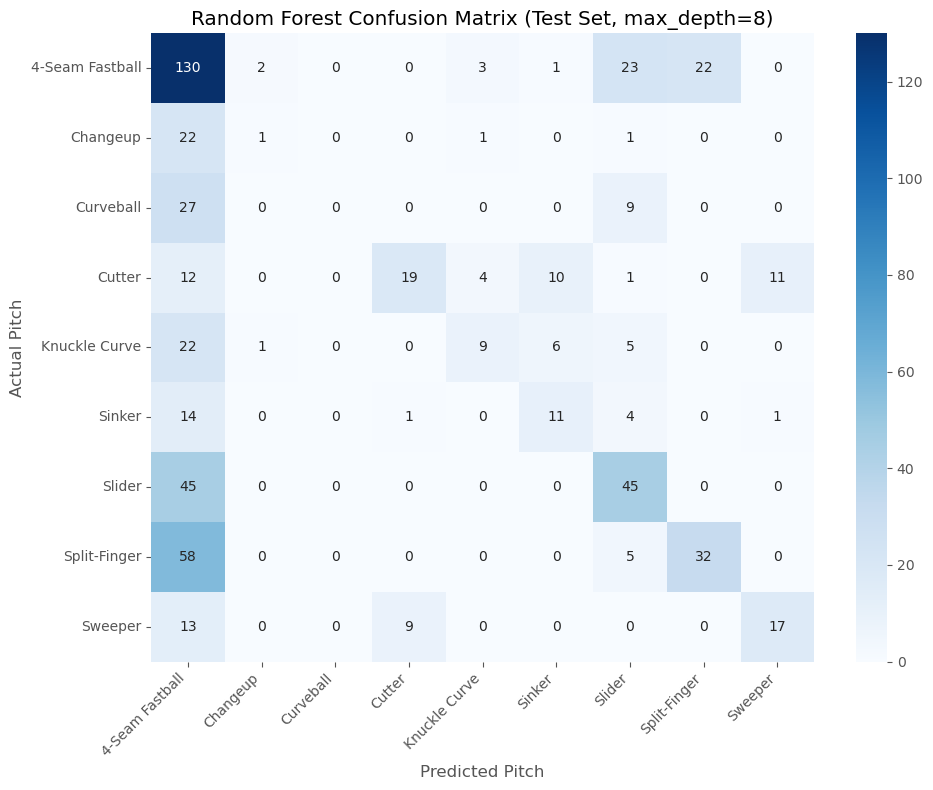

In [ ]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_rf, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Pitch')
plt.ylabel('Actual Pitch')
plt.title(f'Random Forest Confusion Matrix (Test Set, max_depth={best_depth})')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Confusion Matrix Interpretation**

The confusion matrix reveals which pitch types the model can distinguish and which it confuses:
- The **diagonal** cells show correct predictions. Larger values indicate the model is confident and accurate for that pitch type.
- **Off-diagonal** cells highlight systematic misclassifications. For example, if the model frequently predicts "4-Seam Fastball" when the actual pitch is a "Sinker", this makes physical sense since both are fastball-family pitches with similar contexts.
- Rare pitch types (low support) are harder to learn and may be predominantly misclassified as the majority class, which is a known challenge with imbalanced datasets.

### ROC Curves

Since our problem is **multiclass** (9 pitch types), we extend this to the **One-vs-Rest (OvR)** approach: for each pitch type, we treat it as the positive class and all other pitches as the negative class, then compute its own ROC curve and AUC.

A per-class AUC close to 1.0 means the model's predicted probabilities reliably separate that pitch type from all others. The **mean AUC** (average of all per-class AUCs) summarises overall discriminative ability.

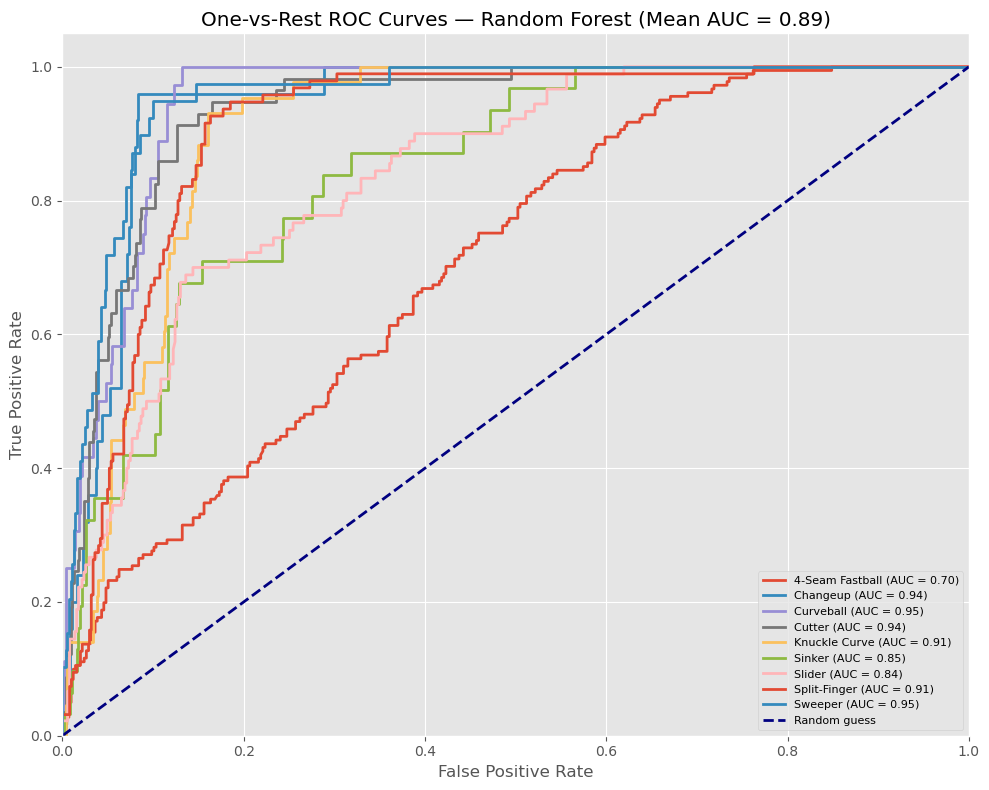

In [ ]:
y_test_bin  = label_binarize(y_test, classes=labels)
y_prob_rf   = rf_final.predict_proba(X_test)

plt.figure(figsize=(10, 8))
line_width = 2
all_auc = {}

for i, label in enumerate(labels):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
    auc_i = auc(fpr_i, tpr_i)
    all_auc[label] = auc_i
    plt.plot(fpr_i, tpr_i, lw=line_width, label=f"{label} (AUC = {auc_i:.2f})")

mean_auc = np.mean(list(all_auc.values()))
plt.plot([0, 1], [0, 1], color='navy', lw=line_width, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'One-vs-Rest ROC Curves — Random Forest (Mean AUC = {mean_auc:.2f})')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

**ROC Curves Interpretation**

Each curve represents the Random Forest's ability to discriminate one pitch type from all others at various probability thresholds. An AUC of 0.50 would be no better than random guessing (the dashed navy line), while 1.00 would be perfect separation.

- Pitch types with **higher AUC** (closer to 1.0) are well-separated by the model's predicted probabilities. These are pitches with distinctive contextual signatures (e.g., a pitcher who only uses a certain pitch in specific counts).
- Pitch types with **lower AUC** (closer to 0.5) are harder to separate from the rest, suggesting they are thrown in similar situations to other pitch types.
- The **mean AUC** is simply the average of each pitch type's individual AUC, giving us a single number to summarise overall discriminative ability.

## Summary and Conclusion

The Random Forest classifier significantly outperforms the naive baseline, demonstrating that **pitch selection is not random** and can be partially predicted from game context. This answers our research question: yes, the next pitch type thrown by a Blue Jays pitcher can be predicted above chance using pitch context and game state.
